In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
test = "../data/test"
test_ds = tf.keras.utils.image_dataset_from_directory(
    test,
    image_size=(224, 224),
    batch_size=32,
    shuffle = False
)

Found 16970 files belonging to 2 classes.


In [3]:
model = tf.keras.models.load_model("../model/MRL_fineTuned.keras")

In [6]:
loss,accuracy = model.evaluate(test_ds)

531/531 ━━━━━━━━━━━━━━━━━━━━ 1270s 2s/step - accuracy: 0.9906 - loss: 0.0245


In [7]:
print(f"Test Loss: {loss*100:.2f}%")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Loss: 2.45%
Test Accuracy: 99.06%


In [ ]:
y_true = np.concatenate([y.numpy() for x, y in test_ds])
y_proba = model.predict(test_ds)



True Labels length: 16970
531/531 ━━━━━━━━━━━━━━━━━━━━ 2071s 4s/step
Predicted Labels length: 16970


In [16]:
print("True Labels Length: ",len(y_true))
y_pred = (y_proba.ravel()>=0.5).astype(int)
print("Predicted Labels Length: ",len(y_pred))

True Labels Length:  16970
Predicted Labels Length:  16970


In [17]:
print(classification_report(y_true, y_pred, target_names= ['Drowsy', 'Alert']))

              precision    recall  f1-score   support

      Drowsy       0.99      0.99      0.99      8580
       Alert       0.99      0.99      0.99      8390

    accuracy                           0.99     16970
   macro avg       0.99      0.99      0.99     16970
weighted avg       0.99      0.99      0.99     16970



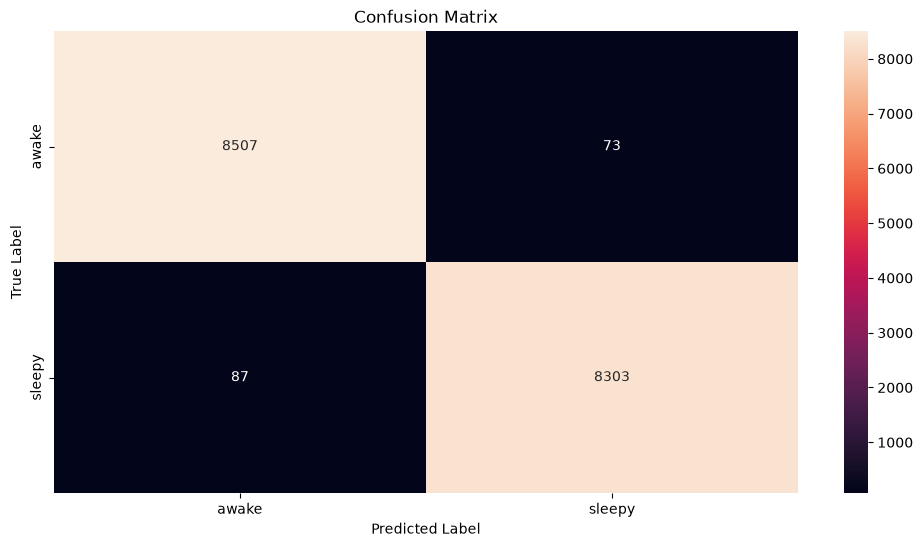

In [18]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=test_ds.class_names,
    yticklabels=test_ds.class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [20]:
misclassified = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Misclassified images:", len(misclassified))
print(
    f"Error Rate: "
    f"{len(misclassified) / len(y_true) * 100:.2f}%"
)

Total test images: 16970
Misclassified images: 160
Error Rate: 0.94%


In [21]:
test_images = np.concatenate(
    [x.numpy() for x, y in test_ds],
    axis=0
)

test_labels = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

print("Images:", test_images.shape)
print("Labels:", test_labels.shape)

Images: (16970, 224, 224, 3)
Labels: (16970,)


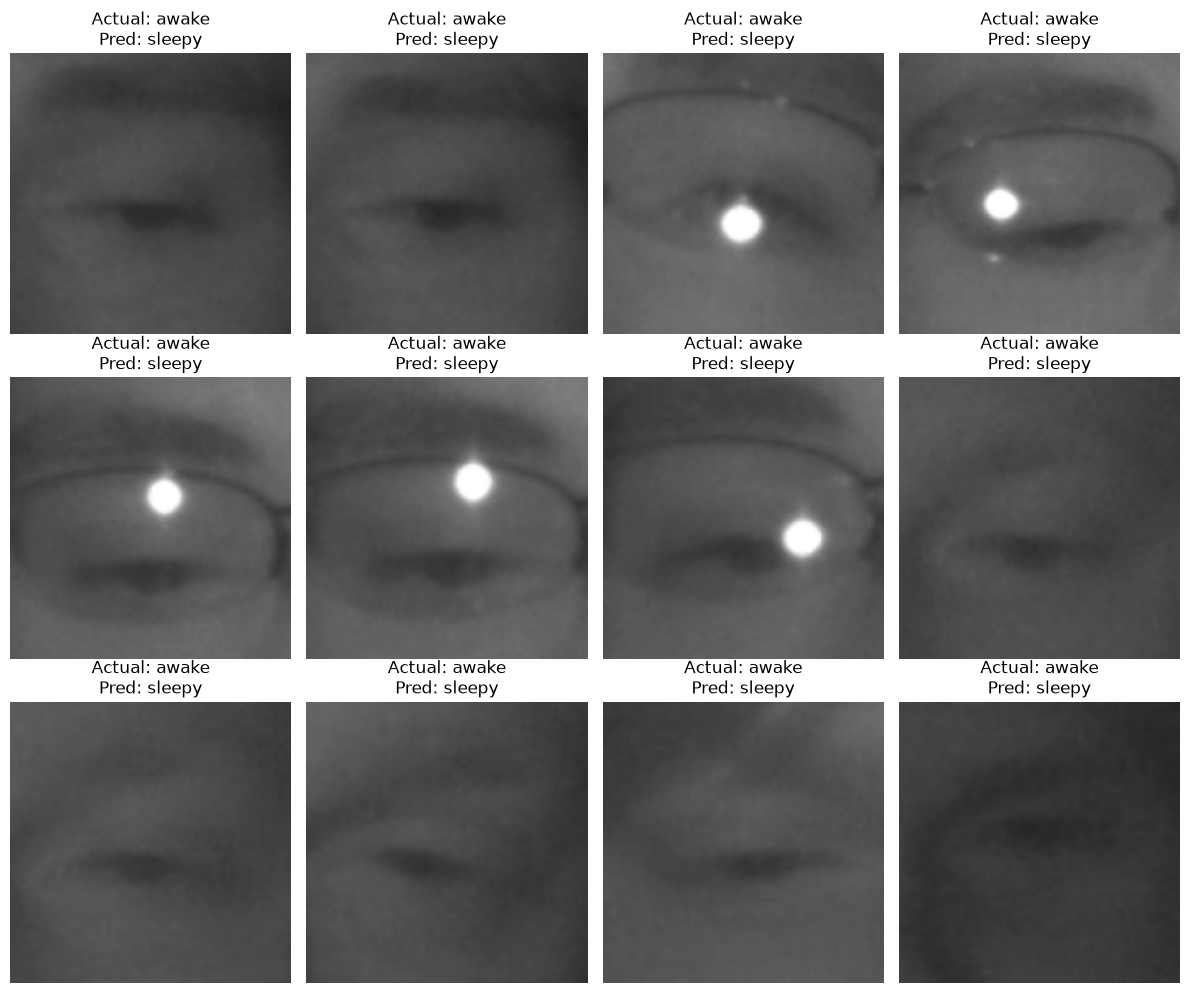

In [22]:
plt.figure(figsize=(12, 10))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    actual = test_ds.class_names[y_true[idx]]
    predicted = test_ds.class_names[y_pred[idx]]

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
confidence = np.where(y_pred==1,y_proba.ravel(),1-y_proba.ravel())
print(f"Average confidence: {confidence.mean() * 100:.2f}%")
print(f"Minimum confidence: {confidence.min() * 100:.2f}%")
print(f"Maximum confidence: {confidence.max() * 100:.2f}%")

Average confidence: 98.93%
Minimum confidence: 50.23%
Maximum confidence: 100.00%


In [24]:
correct = y_true == y_pred
incorrect = y_true != y_pred

print(
    f"Average confidence (Correct): "
    f"{confidence[correct].mean() * 100:.2f}%"
)

print(
    f"Average confidence (Incorrect): "
    f"{confidence[incorrect].mean() * 100:.2f}%"
)

Average confidence (Correct): 99.19%
Average confidence (Incorrect): 70.96%


In [28]:
uncertain = np.abs(y_proba.ravel()-0.5)
most_uncertain = np.argsort(uncertain)[:12]

for idx in most_uncertain:
    print(f"Index : {idx}")
    print(f"True Class Name: {test_ds.class_names[y_true[idx]]}")
    print(f"Predicted Class Name: {test_ds.class_names[y_pred[idx]]}")
    print(f"Confidence : {confidence[idx]*100:.2f}")

Index : 1245
True Class Name: awake
Predicted Class Name: awake
Confidence : 50.23
Index : 4845
True Class Name: awake
Predicted Class Name: sleepy
Confidence : 50.42
Index : 4956
True Class Name: awake
Predicted Class Name: sleepy
Confidence : 50.46
Index : 328
True Class Name: awake
Predicted Class Name: sleepy
Confidence : 50.47
Index : 7405
True Class Name: awake
Predicted Class Name: sleepy
Confidence : 50.50
Index : 15290
True Class Name: sleepy
Predicted Class Name: sleepy
Confidence : 50.57
Index : 8767
True Class Name: sleepy
Predicted Class Name: awake
Confidence : 50.64
Index : 6614
True Class Name: awake
Predicted Class Name: sleepy
Confidence : 50.67
Index : 10164
True Class Name: sleepy
Predicted Class Name: awake
Confidence : 50.75
Index : 16483
True Class Name: sleepy
Predicted Class Name: sleepy
Confidence : 50.80
Index : 15282
True Class Name: sleepy
Predicted Class Name: awake
Confidence : 50.84
Index : 2634
True Class Name: awake
Predicted Class Name: sleepy
Confide

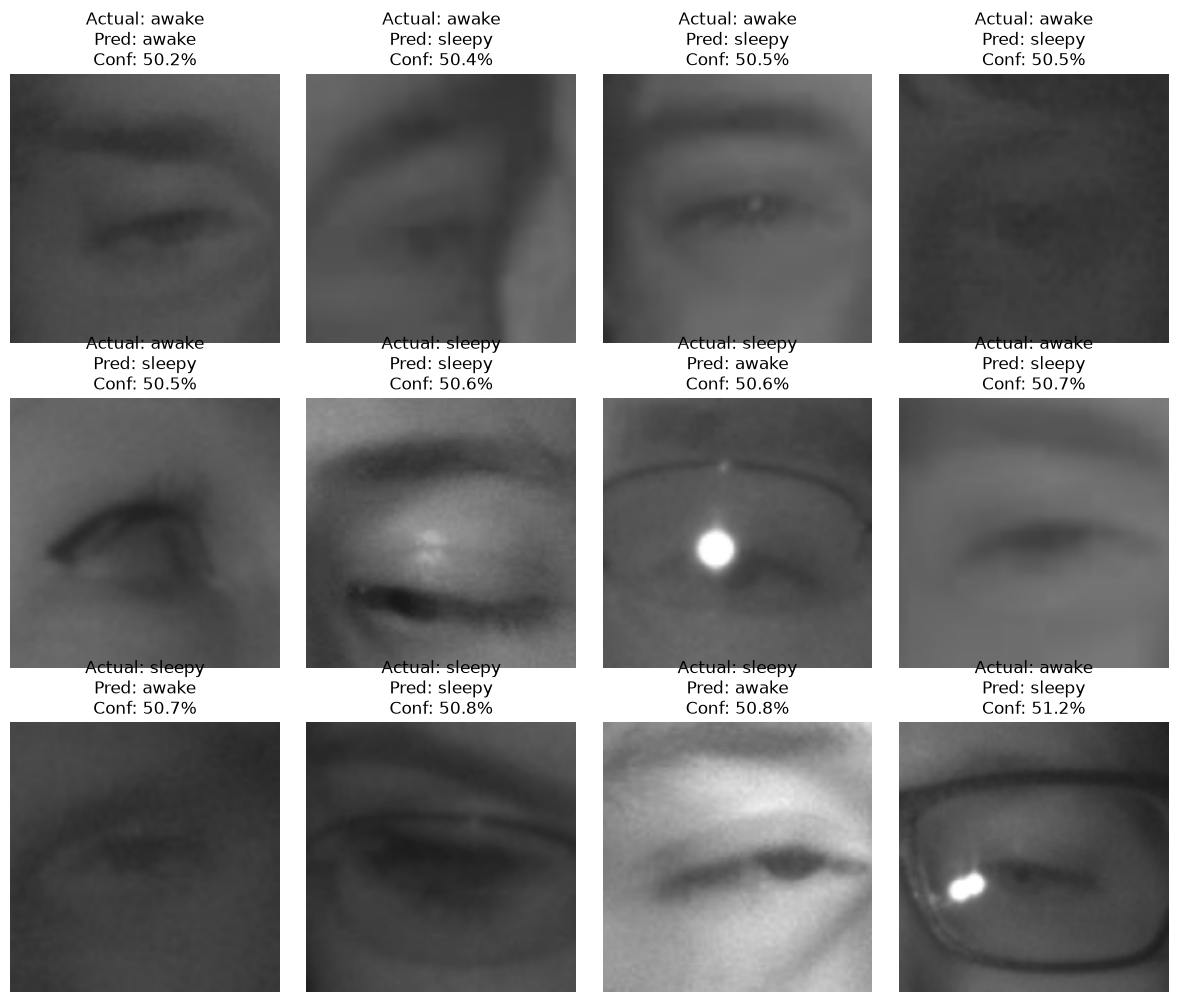

In [29]:
plt.figure(figsize=(12, 10))

for i, idx in enumerate(most_uncertain):
    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    actual = test_ds.class_names[y_true[idx]]
    predicted = test_ds.class_names[y_pred[idx]]

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted}\n"
        f"Conf: {confidence[idx]*100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:


# Final metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

total_samples = len(y_true)
correct_predictions = np.sum(y_true == y_pred)
incorrect_predictions = np.sum(y_true != y_pred)
error_rate = incorrect_predictions / total_samples

# Final Summary
print("=" * 50)
print("           FINAL MODEL EVALUATION")
print("=" * 50)

print(f"Test Samples        : {total_samples:,}")
print(f"Correct Predictions : {correct_predictions:,}")
print(f"Incorrect Predictions: {incorrect_predictions:,}")

print("-" * 50)

print(f"Test Accuracy       : {accuracy * 100:.2f}%")
print(f"Test Loss           : {loss:.4f}")
print(f"Error Rate          : {error_rate * 100:.2f}%")

print("-" * 50)

print(f"Weighted Precision   : {precision * 100:.2f}%")
print(f"Weighted Recall      : {recall * 100:.2f}%")
print(f"Weighted F1-Score    : {f1 * 100:.2f}%")

print("-" * 50)

print("Confusion Matrix:")
print(f"True Awake → Awake   : {tn:,}")
print(f"True Awake → Sleepy  : {fp:,}")
print(f"True Sleepy → Awake  : {fn:,}")
print(f"True Sleepy → Sleepy : {tp:,}")

print("=" * 50)

           FINAL MODEL EVALUATION
Test Samples        : 16,970
Correct Predictions : 16,810
Incorrect Predictions: 160
--------------------------------------------------
Test Accuracy       : 99.06%
Test Loss           : 0.0245
Error Rate          : 0.94%
--------------------------------------------------
Weighted Precision   : 99.06%
Weighted Recall      : 99.06%
Weighted F1-Score    : 99.06%
--------------------------------------------------
Confusion Matrix:
True Awake → Awake   : 8,507
True Awake → Sleepy  : 73
True Sleepy → Awake  : 87
True Sleepy → Sleepy : 8,303


# Final Model Evaluation Summary

## 1. Evaluation Objective

The final trained driver drowsiness detection model was evaluated on a completely held-out test dataset to measure its ability to distinguish between **Awake** and **Sleepy** states on unseen images.

The evaluation was designed to go beyond overall accuracy and included:

* Test loss and accuracy
* Classification report
* Precision, recall, and F1-score
* Confusion matrix analysis
* Misclassification/error analysis
* Prediction confidence analysis
* Analysis of uncertain predictions

---

## 2. Test Dataset

The final evaluation was performed on **16,970 test images**.

| Metric               |     Result |
| -------------------- | ---------: |
| Total Test Images    |     16,970 |
| Awake Images         |      8,580 |
| Sleepy Images        |      8,390 |
| Test Loss            |     0.0245 |
| Test Accuracy        | **99.06%** |
| Error Rate           |  **0.94%** |
| Misclassified Images |    **160** |

The test set contains both classes in relatively similar proportions, making overall accuracy a meaningful metric while still allowing class-wise performance to be evaluated independently.

---

## 3. Overall Model Performance

The final model achieved a **test accuracy of 99.06%**, with a test loss of **0.0245**.

This result is consistent with the approximately **99% validation accuracy** observed during model development. The small difference between validation and test performance indicates that the model maintains strong performance when evaluated on unseen test data.

Out of **16,970** test images:

* **16,810** images were classified correctly.
* Only **160** images were misclassified.

This corresponds to an overall error rate of only **0.94%**.

---

## 4. Classification Performance

The classification report demonstrated strong and balanced performance for both classes.

| Class  | Precision |  Recall | F1-Score |
| ------ | --------: | ------: | -------: |
| Awake  |   ~98.99% | ~99.15% |  ~99.07% |
| Sleepy |   ~99.13% | ~98.96% |  ~99.05% |

The model therefore performs consistently well across both classes rather than achieving high accuracy by favoring one class.

### Awake

The model correctly identifies approximately **99.15% of actual Awake samples**. Only a small number of Awake images are incorrectly classified as Sleepy.

### Sleepy

The model correctly identifies approximately **98.96% of actual Sleepy samples**. This is particularly important for the intended application because failing to identify a genuinely sleepy driver represents a critical type of error.

---

## 5. Confusion Matrix Analysis

The confusion matrix obtained during testing was:

| Actual / Predicted |     Awake |    Sleepy |
| ------------------ | --------: | --------: |
| **Awake**          | **8,507** |        73 |
| **Sleepy**         |        87 | **8,303** |

The diagonal values represent correct predictions, while the off-diagonal values represent misclassifications.

### Key findings

* **8,507 Awake images** were correctly classified as Awake.
* **8,303 Sleepy images** were correctly classified as Sleepy.
* **73 Awake images** were incorrectly classified as Sleepy.
* **87 Sleepy images** were incorrectly classified as Awake.

The two types of errors are relatively balanced, indicating that the model does not exhibit a strong bias toward either class.

Most importantly, the model successfully detected **8,303 out of 8,390 Sleepy samples**, demonstrating a **98.96% recall for the Sleepy class**.

---

## 6. Misclassification Analysis

A total of **160 images** were misclassified out of 16,970 test samples.

This represents only:

**0.94% of the complete test set.**

The misclassified samples represent the cases where the model had difficulty distinguishing between Awake and Sleepy states.

Such errors can occur because some images may contain visually ambiguous conditions, such as:

* Partially closed eyes
* Transitional eye states
* Unusual facial expressions
* Different face orientations
* Poor lighting
* Image blur or low-quality frames
* Visual characteristics that are similar between the two classes

Examining these incorrectly classified images provides useful information about the model's limitations and helps identify challenging cases for future improvement.

---

## 7. Prediction Confidence Analysis

Prediction confidence was also examined to determine how strongly the model supported its decisions.

The analysis considered:

* Average prediction confidence
* Confidence on correctly classified images
* Confidence on incorrectly classified images
* Predictions closest to the 0.5 decision boundary

Predictions close to the decision boundary represent cases where the model is less certain about whether an image represents an Awake or Sleepy state.

These uncertain samples are particularly useful for error analysis because they can reveal visually ambiguous examples that may require additional training data or improved preprocessing.

---

## 8. Evaluation Pipeline Validation

During evaluation, an initial issue was identified in the prediction-processing code.

The model uses a **binary sigmoid output**, meaning each prediction produces a single probability rather than two class probabilities. Initially applying:

```python
np.argmax(y_prob, axis=1)
```

incorrectly converted every prediction to class `0`, producing a misleading confusion matrix and approximately 50% accuracy.

The prediction logic was corrected using a binary threshold:

```python
y_pred = (y_prob.ravel() >= 0.5).astype(int)
```

After correcting the binary prediction interpretation, the confusion matrix and classification results became consistent with the model's `evaluate()` result.

This validation step confirms that the final reported performance is based on the correct interpretation of the model's output.

---

## 9. Final Findings

The final model demonstrates **excellent performance on the held-out test dataset**, achieving:

* **99.06% test accuracy**
* **0.94% error rate**
* **0.0245 test loss**
* Approximately **99% precision, recall, and F1-score for both classes**
* **98.96% recall for the Sleepy class**
* Only **160 misclassified images out of 16,970**

The close agreement between validation and test accuracy also suggests that the model generalizes well from the development data to the unseen test set.

The confusion matrix further shows that the model performs well on **both Awake and Sleepy classes**, rather than simply predicting the majority class.

---

## 10. Overall Conclusion

The final trained model provides a highly accurate binary classification system for distinguishing between **Awake** and **Sleepy** facial states.

With a test accuracy of **99.06%** and Sleepy-class recall of approximately **98.96%**, the model demonstrates strong potential for use as the core visual classification component of a driver drowsiness detection system.

However, these results should be interpreted as **image-level classification performance**. A practical driver-monitoring system would require additional evaluation under real-world conditions, including continuous video streams, different drivers, varying illumination, different camera positions, occlusions such as glasses, and other environmental factors.

Therefore, while the final model demonstrates excellent performance on the available test dataset, further real-world and subject-independent validation would be necessary before considering deployment in a safety-critical driving environment.

### Final Performance

> **Test Accuracy: 99.06%**
> **Test Loss: 0.0245**
> **Misclassification Rate: 0.94%**
> **Sleepy Recall: ~98.96%**
> **Total Test Samples: 16,970**

Overall, the evaluation confirms that the final model is a **high-performing classifier on the held-out test dataset**, while also identifying real-world validation and generalization as the key areas for future work.
